In [ ]:
!pip install -r ..\..\requirements.txt

In [11]:
1

1

In [12]:
from datetime import datetime
from zoneinfo import ZoneInfo
from drawdata import ScatterWidget
from sqlalchemy import create_engine
import dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import irisnative as iris
import json

dotenv.load_dotenv()

connection_params = {
    "hostname": os.getenv("IRIS_SERVER"),
    "port": int(os.getenv("IRIS_PORT")),
    "namespace": os.getenv("IRIS_NAMESPACE"),
    "username": os.getenv("IRIS_USERNAME"),
    "password": os.getenv("IRIS_PASSWORD")
}


### Create Points

In [13]:
datetime_now = datetime.now(tz=ZoneInfo(os.getenv("TZ")))
datetime_now_str = datetime_now.strftime("%Y-%m-%d %H:%M:%S")
widget = ScatterWidget(height=400, width=400)
widget

In [14]:
df = widget.data_as_pandas[["x", "y", "label"]]
df["datetime"] = datetime_now_str
df.head()

,x,y,label,datetime
0,7.274087,396.067191,a,2026-06-15 16:37:32
1,21.528898,381.353740,a,2026-06-15 16:37:32
2,12.214609,393.620553,a,2026-06-15 16:37:32
3,43.520625,391.361092,a,2026-06-15 16:37:32
4,75.885540,379.036674,a,2026-06-15 16:37:32


### Sample Aplifier

(needed because this example implies groups of samples and manually drawing many samples would take too much time)

In [15]:
# SAMPLE AMPLIFIER

import numpy as np

numnewsamples = 10  # number of new samples needed
pointnoise = 1      # noise scale to add to x and y
timediff = 1        # seconds between successive new sample datetimes

base_datetime = datetime_now
new_samples = [df]
for i in range(numnewsamples):
    base_df = df[["x", "y", "label"]].copy()
    base_df["x"] += np.random.normal(0, pointnoise, size=base_df.shape[0])
    base_df["y"] += np.random.normal(0, pointnoise, size=base_df.shape[0])
    base_df["datetime"] = (base_datetime + pd.Timedelta(seconds=timediff * (i + 1))).strftime("%Y-%m-%d %H:%M:%S")
    new_samples.append(base_df)

df = pd.concat(new_samples, ignore_index=True)

In [16]:
engine = create_engine(f"iris://{connection_params['username']}:{connection_params['password']}@{connection_params['hostname']}:{connection_params['port']}/{connection_params['namespace']}")
df.to_sql("PointSamples", engine, schema="MLpipeline", if_exists='append', index=False, method=None)

-1

### Prediction Testing

Weighted F1 Score: 0.4208


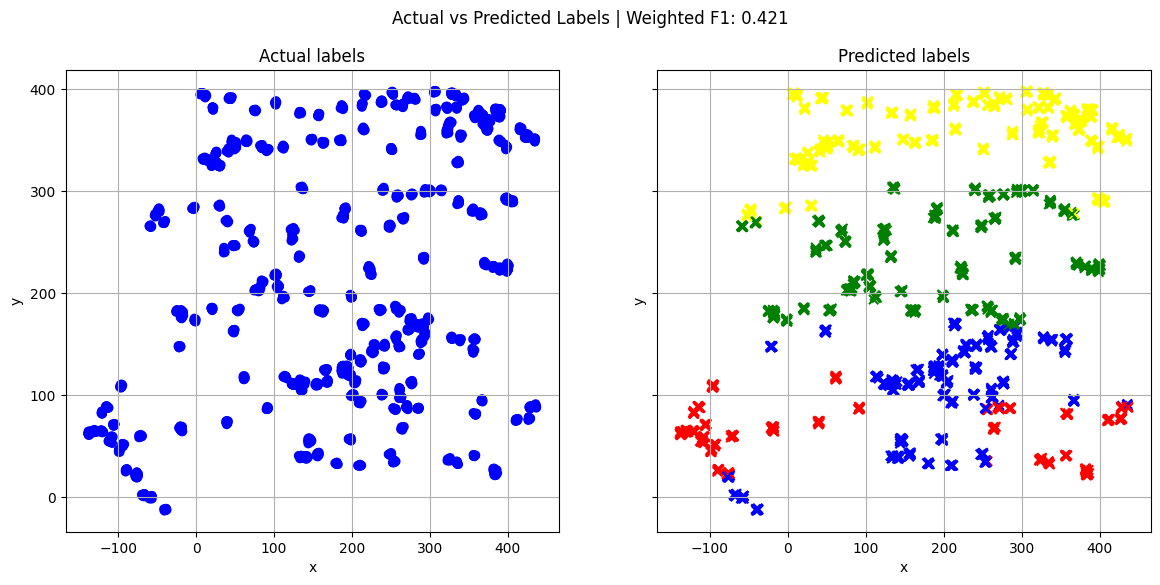

: 

In [ ]:
from sklearn.metrics import f1_score

color_map = {'a': 'blue', 'b': 'yellow', 'c': 'green', 'd': 'red'}

date_filter = f"datetime >= '{datetime_now_str}'"

with iris.createConnection(**connection_params) as conn:
    iris_obj = iris.createIris(conn)
    json_result = iris_obj.classMethodValue("MLpipeline.PredictionService", "Predict", date_filter)
    predictions = json.loads(json_result)

y_true = df["label"].astype(str).tolist()
y_pred = [str(p) for p in predictions]

if len(y_pred) != len(y_true):
    raise ValueError(f"Expected {len(y_true)} predictions, got {len(y_pred)}")

f1 = f1_score(y_true, y_pred, average="weighted")
print(f"Weighted F1 Score: {f1:.4f}")

label_colors_true = [color_map.get(v, "gray") for v in y_true]
label_colors_pred = [color_map.get(v, "gray") for v in y_pred]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(df["x"], df["y"], c=label_colors_true, s=35)
axes[0].set_title("Actual labels")

axes[1].scatter(df["x"], df["y"], c=label_colors_pred, marker="x", s=45)
axes[1].set_title("Predicted labels")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)

fig.suptitle(f"Actual vs Predicted Labels | Weighted F1: {f1:.3f}")
plt.show()


### Monitoring Testing

In [8]:
with iris.createConnection(**connection_params) as conn:
    iris_obj = iris.createIris(conn)
    PM = iris_obj.classMethodObject("MLpipeline.PerformanceMonitoring", "%New")
    status = PM.invoke("MetricsMonitoring",datetime_now_str)
print(f"Performance monitoring status: {status}")

🏃 View run bouncy-koi-195 at: http://mlflow:5000/#/experiments/6/runs/eb9c890dc2a54d3eb1248d94fd645c51
🧪 View experiment at: http://mlflow:5000/#/experiments/6
🏃 View run bouncy-koi-195 at: http://mlflow:5000/#/experiments/6/runs/eb9c890dc2a54d3eb1248d94fd645c51
🧪 View experiment at: http://mlflow:5000/#/experiments/6
🏃 View run treasured-bee-74 at: http://mlflow:5000/#/experiments/7/runs/3da64e294d4d4d378bf5267070b4a25a
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run trial_0 at: http://mlflow:5000/#/experiments/7/runs/eba970fdd51d47c59071420f928c07e6
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run trial_1 at: http://mlflow:5000/#/experiments/7/runs/1c6fa18c5fb24c648d940d9cc2b30d8d
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run trial_2 at: http://mlflow:5000/#/experiments/7/runs/399ceb0f350b4f9b8b1158aa906584d1
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run trial_3 at: http://mlflow:5000/#/experiments/7/r